In [3]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\SuperGan\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib (from versions: none)
ERROR: No matching distribution found for matplotlib
You should consider upgrading via the 'c:\Users\SuperGan\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [4]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\SuperGan\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


Backtesting SPY from 2005-11-30 to 2025-11-30...


C:\Users\SuperGan\AppData\Local\Temp\ipykernel_20308\735755154.py:105: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=download_start, end=end_date)
[*********************100%***********************]  1 of 1 completed


--- SPY Performance ---
Period: 2005-11-30 to 2025-11-30
Buy rule: deep dip <= 9% below 200-day SMA (threshold=0.90)
Strategy CAGR: 11.46%
Buy and Hold CAGR: 10.90%
Strategy Max Drawdown: -40.84%
Buy and Hold Max Drawdown: -55.19%
Initial Capital: $1,500,000
Final Strategy Portfolio Value: $13,126,210.05
Final Buy & Hold Portfolio Value: $11,868,431.02




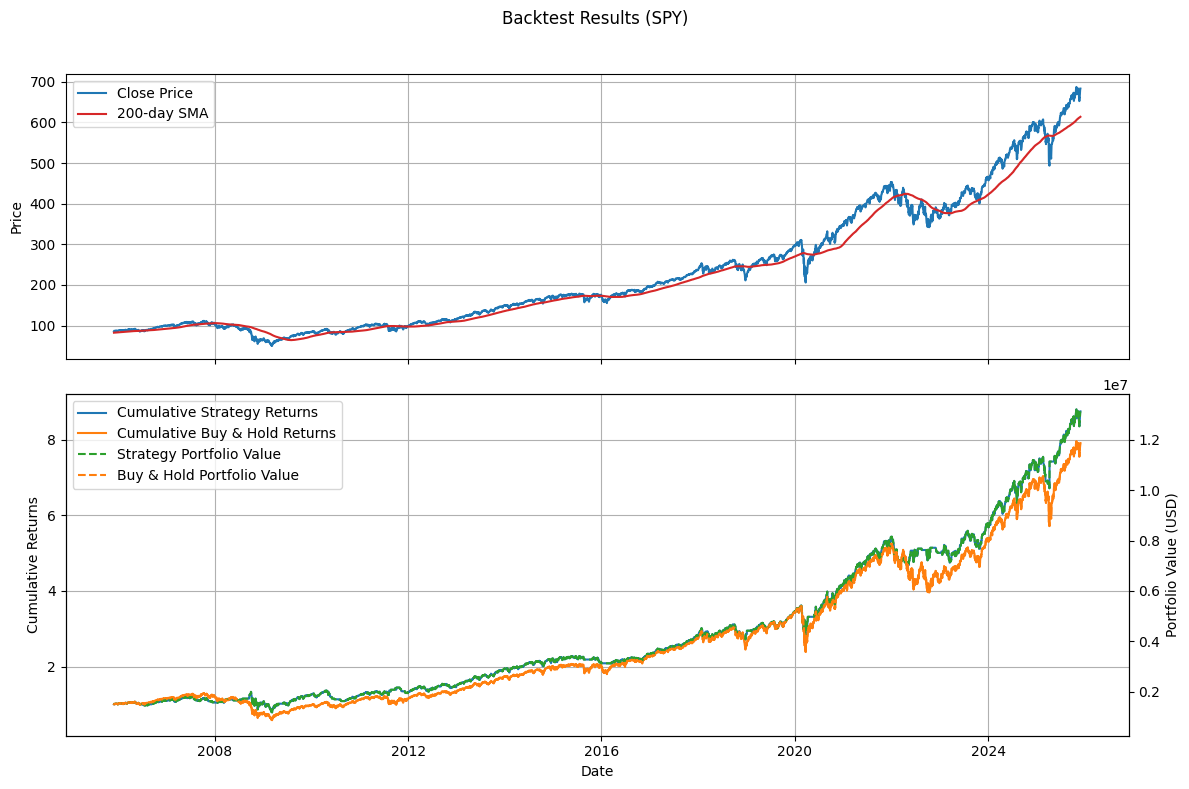

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# List of tickers to backtest (single ticker recommended for quick runs)
tickers = ['SPY']
# tickers = ['ASHR']

# Input date range as strings in 'YYYY-MM-DD' format (change these as needed)
start_date_str = '2005-11-30'
end_date_str = '2025-11-30'

# Parse input dates
start_date = pd.to_datetime(start_date_str)
end_date = pd.to_datetime(end_date_str)

# SMA window and buy threshold
sma_window = 200
buy_threshold = 0.95  # 0.9 == 10% below 200-day SMA

# Initial portfolio capital
initial_capital = 1_500_000


def calculate_max_drawdown(cumulative_returns):
    """
    Calculate the maximum drawdown from a cumulative returns series.
    """
    running_max = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns - running_max) / running_max
    return drawdown.min()


def plot_results(df, start=None, end=None, title_suffix=''):
    """
    Standalone plotting function.
    - `df` should contain the columns:
      'Close', 'SMA' (optional),
      'Cumulative_Strategy_Returns', 'Cumulative_Buy_and_Hold_Returns',
      'Strategy_Portfolio_Value', 'Buy_and_Hold_Portfolio_Value'
    - `start` / `end` are optional date strings (e.g. '2020-01-01') or Timestamps.
    """
    plot_df = df.copy()
    if start is not None or end is not None:
        plot_df = plot_df.loc[start:end]

    # Create two stacked subplots: price+SMA on top, cumulative returns+portfolio values below
    fig, (ax0, ax1) = plt.subplots(2, 1, sharex=True, figsize=(12, 8), gridspec_kw={'height_ratios': [1, 1.2]})

    # Top: Price and SMA
    if 'Close' in plot_df.columns:
        ax0.plot(plot_df.index, plot_df['Close'], label='Close Price', color='tab:blue')
    if 'SMA' in plot_df.columns:
        ax0.plot(plot_df.index, plot_df['SMA'], label=f'{sma_window}-day SMA', color='tab:red')
    ax0.set_ylabel('Price')
    ax0.legend(loc='upper left')
    ax0.grid(True)

    # Bottom: cumulative returns and portfolio values
    ax1.plot(plot_df.index, plot_df['Cumulative_Strategy_Returns'], label='Cumulative Strategy Returns')
    ax1.plot(plot_df.index, plot_df['Cumulative_Buy_and_Hold_Returns'], label='Cumulative Buy & Hold Returns')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Cumulative Returns')
    ax1.legend(loc='upper left')
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(plot_df.index, plot_df['Strategy_Portfolio_Value'], color='tab:green', linestyle='--', label='Strategy Portfolio Value')
    ax2.plot(plot_df.index, plot_df['Buy_and_Hold_Portfolio_Value'], color='tab:orange', linestyle='--', label='Buy & Hold Portfolio Value')
    ax2.set_ylabel('Portfolio Value (USD)')

    # combine legends for the bottom plot
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    if title_suffix:
        fig.suptitle(f'Backtest Results {title_suffix}', y=0.98)
    else:
        fig.suptitle('Backtest Results', y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def backtest_ma_strategy(ticker, start_date, end_date, sma_window=sma_window, buy_threshold=buy_threshold, initial_capital=initial_capital):
    """
    Backtests a moving average strategy for a given ticker.

    Rules & behavior:
    - Start: invest the full `initial_capital` in the asset at the first available close within the requested period.
    - Signals use prior-day SMA so the strategy remains aligned at the start.
    - Download additional history before `start_date` so SMA is available on the requested start date.
    - Signal priority: deep-dip buy (price <= buy_threshold * SMA_prev) > price above SMA_prev buy.
    - Trades execute at the day's close. A buy only occurs if cash > 0 (i.e. after a prior sell).
    - Strategy holds either full position (all capital invested) or cash (no partial sizing), fractional shares allowed.
    """
    print(f"Backtesting {ticker} from {start_date.date()} to {end_date.date()}...")

    # To compute SMA at the requested start_date, download extra history before start_date
    pad_days = int(sma_window * 3)
    download_start = start_date - pd.DateOffset(days=pad_days)

    # Download historical data from padded start
    data = yf.download(ticker, start=download_start, end=end_date)
    if data.empty:
        print("No data downloaded for", ticker)
        return pd.DataFrame()

    # Flatten MultiIndex columns if they exist
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.droplevel(1)

    data.index = pd.to_datetime(data.index)

    # Calculate SMA on the extended history so SMA is available at the requested start_date
    data['SMA'] = data['Close'].rolling(window=sma_window).mean()
    data['SMA_prev'] = data['SMA'].shift(1)

    # Now trim to the requested period for the rest of the simulation and reporting
    data = data.loc[start_date:end_date].copy()
    if data.empty:
        print('No data in the requested date range after trimming to start/end')
        return pd.DataFrame()

    # Initialize signals
    data['Signal'] = 0
    # Where prior-day SMA exists use the SMA_prev-based rules
    valid = data['SMA_prev'].notna()
    data.loc[valid & (data['Close'] <= (buy_threshold * data['SMA_prev'])), 'Signal'] = 1
    data.loc[valid & (data['Close'] > data['SMA_prev']), 'Signal'] = 1
    # If prior-day SMA is not available (very early rows), treat as invested
    data.loc[data['SMA_prev'].isna(), 'Signal'] = 1

    # Initialize trading simulation columns
    data['Strategy_Shares'] = 0.0
    data['Strategy_Cash'] = 0.0
    data['Strategy_Portfolio_Value'] = 0.0

    # Buy & Hold baseline: buy at first close within requested period with full capital
    first_close_idx = data['Close'].first_valid_index()
    if first_close_idx is None:
        print("No valid close price for", ticker, "in the requested period")
        return pd.DataFrame()

    first_price = data.loc[first_close_idx, 'Close']
    bh_shares = initial_capital / first_price
    data['Buy_and_Hold_Portfolio_Value'] = bh_shares * data['Close']
    data['Cumulative_Buy_and_Hold_Returns'] = data['Buy_and_Hold_Portfolio_Value'] / initial_capital

    # Strategy starts fully invested at first close within requested period
    strategy_shares = initial_capital / first_price
    strategy_cash = 0.0
    in_position = True if strategy_shares > 0 else False

    # Set initial row
    data.loc[first_close_idx, 'Strategy_Shares'] = strategy_shares
    data.loc[first_close_idx, 'Strategy_Cash'] = strategy_cash
    data.loc[first_close_idx, 'Strategy_Portfolio_Value'] = strategy_shares * data.loc[first_close_idx, 'Close'] + strategy_cash

    # Iterate through subsequent dates and execute trades at close based on Signal
    idxs = list(data.index)
    start_pos = idxs.index(first_close_idx)
    for dt in idxs[start_pos+1:]:
        price = data.loc[dt, 'Close']
        sig = data.loc[dt, 'Signal']

        # If currently in position and signal is 0 -> sell (go to cash)
        if in_position and sig == 0:
            strategy_cash = strategy_shares * price
            strategy_shares = 0.0
            in_position = False

        # If not in position and signal is 1 -> buy only if we have cash
        elif (not in_position) and sig == 1 and strategy_cash > 0:
            # buy with all available cash (fractional shares allowed)
            strategy_shares = strategy_cash / price
            strategy_cash = 0.0
            in_position = True

        # else: hold current state
        data.loc[dt, 'Strategy_Shares'] = strategy_shares
        data.loc[dt, 'Strategy_Cash'] = strategy_cash
        data.loc[dt, 'Strategy_Portfolio_Value'] = strategy_shares * price + strategy_cash

    # Forward-fill any initial NaNs (if any)
    data['Strategy_Shares'].ffill(inplace=True)
    data['Strategy_Cash'].ffill(inplace=True)
    data['Strategy_Portfolio_Value'].ffill(inplace=True)

    # Cumulative returns for strategy
    data['Cumulative_Strategy_Returns'] = data['Strategy_Portfolio_Value'] / initial_capital
    data['Strategy_Returns'] = data['Strategy_Portfolio_Value'].pct_change().fillna(0)

    # Performance metrics
    valid_start = data['Cumulative_Buy_and_Hold_Returns'].first_valid_index()
    if valid_start is None:
        years = 1
    else:
        years = max((data.index[-1] - valid_start).days / 365.25, 1e-9)

    strategy_cagr = data['Cumulative_Strategy_Returns'].iloc[-1] ** (1/years) - 1
    buy_and_hold_cagr = data['Cumulative_Buy_and_Hold_Returns'].iloc[-1] ** (1/years) - 1
    strategy_max_drawdown = calculate_max_drawdown(data['Cumulative_Strategy_Returns'])
    buy_and_hold_max_drawdown = calculate_max_drawdown(data['Cumulative_Buy_and_Hold_Returns'])

    final_strategy_value = data['Strategy_Portfolio_Value'].iloc[-1]
    final_bh_value = data['Buy_and_Hold_Portfolio_Value'].iloc[-1]

    # Print final performance
    print(f"--- {ticker} Performance ---")
    print(f"Period: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
    print(f"Buy rule: deep dip <= {int((1-buy_threshold)*100)}% below {sma_window}-day SMA (threshold={buy_threshold:.2f})")
    print(f"Strategy CAGR: {strategy_cagr:.2%}")
    print(f"Buy and Hold CAGR: {buy_and_hold_cagr:.2%}")
    print(f"Strategy Max Drawdown: {strategy_max_drawdown:.2%}")
    print(f"Buy and Hold Max Drawdown: {buy_and_hold_max_drawdown:.2%}")
    print(f"Initial Capital: ${initial_capital:,.0f}")
    print(f"Final Strategy Portfolio Value: ${final_strategy_value:,.2f}")
    print(f"Final Buy & Hold Portfolio Value: ${final_bh_value:,.2f}")
    print("\n")

    # Default full-period plot
    plot_results(data, title_suffix=f"({ticker})")

    return data


# Run the backtest for each ticker and collect results in a dict
results = {}
for ticker in tickers:
    results[ticker] = backtest_ma_strategy(ticker, start_date, end_date)

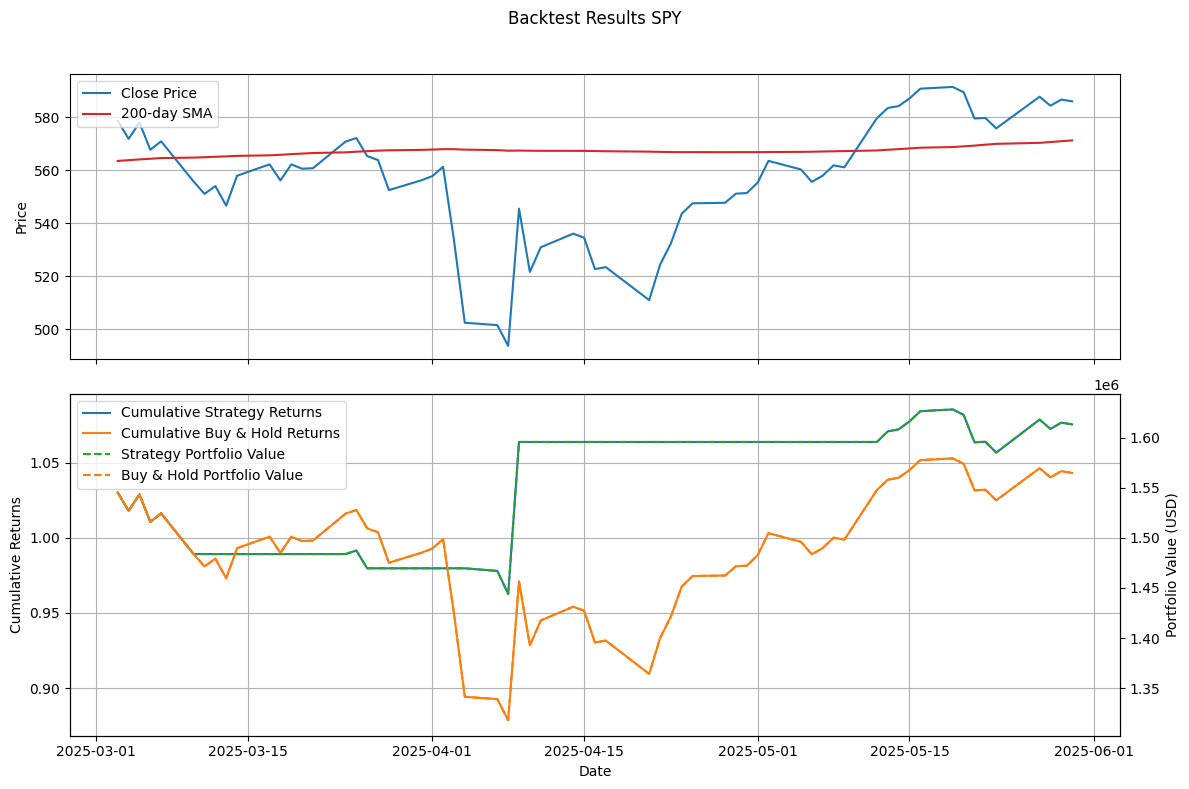

In [21]:
plot_results(results[ticker], '2025-03-01', '2025-06-01', ticker)

In [27]:
# show OHLC price data for the requested date range
price_slice = results[ticker].loc['2025-03-01':'2025-06-01', ]
price_slice.to_csv("qc_sma_res.csv")